In [88]:
import time
import numpy as np
import pandas as pd
import os
from tqdm import tqdm

from goodpoints import compress
from openxai.model import LoadModel
from openxai.dataloader import ReturnLoaders
import sage
import shap

np.random.seed(0)

ground_truth_repeat = 3
cte_repeat = 5


data_name = 'compas'

_, loader_test = ReturnLoaders(data_name=data_name, download=False, batch_size=128)
X_test, y_test = loader_test.dataset.data, loader_test.dataset.targets.to_numpy()

n_samples_total = X_test.shape[0]
n_features = X_test.shape[1]

values_cte_path = f'../metadata/{data_name}/cte_shap_sage_results_0_{cte_repeat}.npy'
times_cte_info_path = f'../metadata/{data_name}/cte_shap_sage_times_0_{cte_repeat}.csv'

values_gt_path = f'../metadata/{data_name}/ground_truth_shap_sage_results_0_{ground_truth_repeat}.npy'
times_gt_info_path = f'../metadata/{data_name}/ground_truth_shap_sage_times_0_{ground_truth_repeat}.csv'


load cte methods data

In [89]:
values_cte = np.load(values_cte_path, allow_pickle=True).item()
times_cte_info = pd.read_csv(times_cte_info_path)
times_cte_info

,dataset,repeat,method,time_explanation,time_sample_choose,n_original,n_sample,g
0,compas,0,cte_shap_kernel,19.240106,0.003638,1235,64,1
1,compas,0,cte_shap_permutation,14.979462,0.003638,1235,64,1
2,compas,0,cte_sage_kernel,15.876828,0.003638,1235,64,1
3,compas,0,cte_sage_permutation,26.308262,0.003638,1235,64,1
4,compas,0,cte_with_predictions_shap_kernel,22.129898,0.001275,1235,64,1
...,...,...,...,...,...,...,...,...
235,compas,4,cte_stratified_sage_permutation,126.511523,0.002039,1235,192,3
236,compas,4,iid_shap_kernel,96.861917,0.000057,1235,256,3
237,compas,4,iid_shap_permutation,45.334608,0.000057,1235,256,3
238,compas,4,iid_sage_kernel,73.527303,0.000057,1235,256,3


load ground truth

In [90]:
values_gt = np.load(values_gt_path, allow_pickle=True).item()
times_gt_info = pd.read_csv(times_gt_info_path)
times_gt_info['n_sample'] = n_samples_total
times_gt_info

,dataset,repeat,method,time_explanation,n_original,n_sample
0,compas,0,ground_truth_sage_kernel,484.431584,1235,1235
1,compas,0,ground_truth_sage_permutation,1129.337446,1235,1235
2,compas,0,ground_truth_shap_kernel,412.195494,1235,1235
3,compas,0,ground_truth_shap_permutation,193.342111,1235,1235
4,compas,1,ground_truth_sage_kernel,504.969749,1235,1235
5,compas,1,ground_truth_sage_permutation,11440.054044,1235,1235
6,compas,1,ground_truth_shap_kernel,7013.220597,1235,1235
7,compas,1,ground_truth_shap_permutation,2233.695652,1235,1235
8,compas,2,ground_truth_sage_kernel,6777.418669,1235,1235
9,compas,2,ground_truth_sage_permutation,1052.645446,1235,1235


### FILTER: leave only iid, cte, cte_stratified, cte with predictions for SHAP+Kernel and SAGE+Permutation
### SPLIT into 2 dataframes

In [91]:
times_gt_info = times_gt_info[
    times_gt_info['method'].isin([
        'ground_truth_shap_kernel', 
        'ground_truth_sage_permutation'
    ])
]

times_gt_info

,dataset,repeat,method,time_explanation,n_original,n_sample
1,compas,0,ground_truth_sage_permutation,1129.337446,1235,1235
2,compas,0,ground_truth_shap_kernel,412.195494,1235,1235
5,compas,1,ground_truth_sage_permutation,11440.054044,1235,1235
6,compas,1,ground_truth_shap_kernel,7013.220597,1235,1235
9,compas,2,ground_truth_sage_permutation,1052.645446,1235,1235
10,compas,2,ground_truth_shap_kernel,407.542571,1235,1235


In [92]:
values_gt = {
    key: value for key, value in values_gt.items()
    if key in ['ground_truth_shap_kernel', 'ground_truth_sage_permutation']
}
values_gt.keys()

dict_keys(['ground_truth_sage_permutation', 'ground_truth_shap_kernel'])

In [93]:
times_cte_info = times_cte_info[
    times_cte_info['method'].isin([
        'cte_shap_kernel', 
        'cte_sage_permutation', 
        'cte_with_predictions_shap_kernel', 
        'cte_with_predictions_sage_permutation', 
        'cte_stratified_shap_kernel', 
        'cte_stratified_sage_permutation',
        'iid_shap_kernel',
        'iid_sage_permutation'
    ])
]
times_cte_info

,dataset,repeat,method,time_explanation,time_sample_choose,n_original,n_sample,g
0,compas,0,cte_shap_kernel,19.240106,0.003638,1235,64,1
3,compas,0,cte_sage_permutation,26.308262,0.003638,1235,64,1
4,compas,0,cte_with_predictions_shap_kernel,22.129898,0.001275,1235,64,1
7,compas,0,cte_with_predictions_sage_permutation,38.599119,0.001275,1235,64,1
8,compas,0,cte_stratified_shap_kernel,18.329263,0.000537,1235,48,1
...,...,...,...,...,...,...,...,...
231,compas,4,cte_with_predictions_sage_permutation,181.099091,0.012703,1235,256,3
232,compas,4,cte_stratified_shap_kernel,73.592948,0.002039,1235,192,3
235,compas,4,cte_stratified_sage_permutation,126.511523,0.002039,1235,192,3
236,compas,4,iid_shap_kernel,96.861917,0.000057,1235,256,3


In [94]:
values_cte = {
    key: value for key, value in values_cte.items()
    if key in ['cte_shap_kernel', 'cte_sage_permutation', 'cte_with_predictions_shap_kernel', 'cte_with_predictions_sage_permutation', 'cte_stratified_shap_kernel', 'cte_stratified_sage_permutation', 'iid_shap_kernel', 'iid_sage_permutation']
}
values_cte.keys()

dict_keys(['cte_shap_kernel', 'cte_sage_permutation', 'cte_with_predictions_shap_kernel', 'cte_with_predictions_sage_permutation', 'cte_stratified_shap_kernel', 'cte_stratified_sage_permutation', 'iid_shap_kernel', 'iid_sage_permutation'])

### count mean for ground_truth

In [95]:
methods = ['ground_truth_sage_permutation', 'ground_truth_shap_kernel']

values_gt_ = {
    method: np.mean(
        np.array([values_gt[method][i] for i in range(ground_truth_repeat)]),
        axis=0
    )
    for method in methods
}

values_gt = values_gt_
values_cte.keys()

dict_keys(['cte_shap_kernel', 'cte_sage_permutation', 'cte_with_predictions_shap_kernel', 'cte_with_predictions_sage_permutation', 'cte_stratified_shap_kernel', 'cte_stratified_sage_permutation', 'iid_shap_kernel', 'iid_sage_permutation'])

### MAE lineplots

In [96]:
def metric_mae(x, y):
    return np.mean(np.abs(x-y))

SAGE+ Permutation

In [97]:
times_cte_info_ = times_cte_info[
    times_cte_info['method'].isin([
        'cte_sage_permutation', 
        'cte_with_predictions_sage_permutation', 
        'cte_stratified_sage_permutation',
        'iid_sage_permutation'
    ])
]


In [98]:
ground_truth = values_gt['ground_truth_sage_permutation']

mae_list = []

method_indices = {method: 0 for method in values_cte.keys()}

for _, row in times_cte_info_.iterrows():
    method = row['method']
    
    current_index = method_indices[method]
    values_cte_ = values_cte[method][current_index]
    
    method_indices[method] += 1
    
    mae = metric_mae(values_cte_, ground_truth)
    mae_list.append(mae)  

times_cte_info_['mae'] = mae_list

times_cte_info_

,dataset,repeat,method,time_explanation,time_sample_choose,n_original,n_sample,g,mae
3,compas,0,cte_sage_permutation,26.308262,0.003638,1235,64,1,0.017392
7,compas,0,cte_with_predictions_sage_permutation,38.599119,0.001275,1235,64,1,0.010564
11,compas,0,cte_stratified_sage_permutation,38.350254,0.000537,1235,48,1,0.005444
15,compas,0,iid_sage_permutation,35.339050,0.000876,1235,64,1,0.015740
19,compas,1,cte_sage_permutation,33.470743,0.001647,1235,64,1,0.008751
23,compas,1,cte_with_predictions_sage_permutation,45.241058,0.001749,1235,64,1,0.018040
27,compas,1,cte_stratified_sage_permutation,23.721289,0.000579,1235,48,1,0.010469
31,compas,1,iid_sage_permutation,45.895217,0.000051,1235,64,1,0.027157
35,compas,2,cte_sage_permutation,21.921126,0.001670,1235,64,1,0.026072
39,compas,2,cte_with_predictions_sage_permutation,41.299266,0.002057,1235,64,1,0.014116


In [99]:
import pandas as pd
import matplotlib.pyplot as plt

agg_df = times_cte_info_.groupby(['method', 'n_sample']).agg(
    mean=('mae', 'mean'),
    std=('mae', 'std')
).reset_index()

method_labels = {
    "iid_sage_permutation": "iid",
    "cte_sage_permutation": "cte",
    "cte_with_predictions_sage_permutation": "cte-predictions",
    "cte_stratified_sage_permutation": "cte-stratified",
}

label=method_labels.get(method, method)

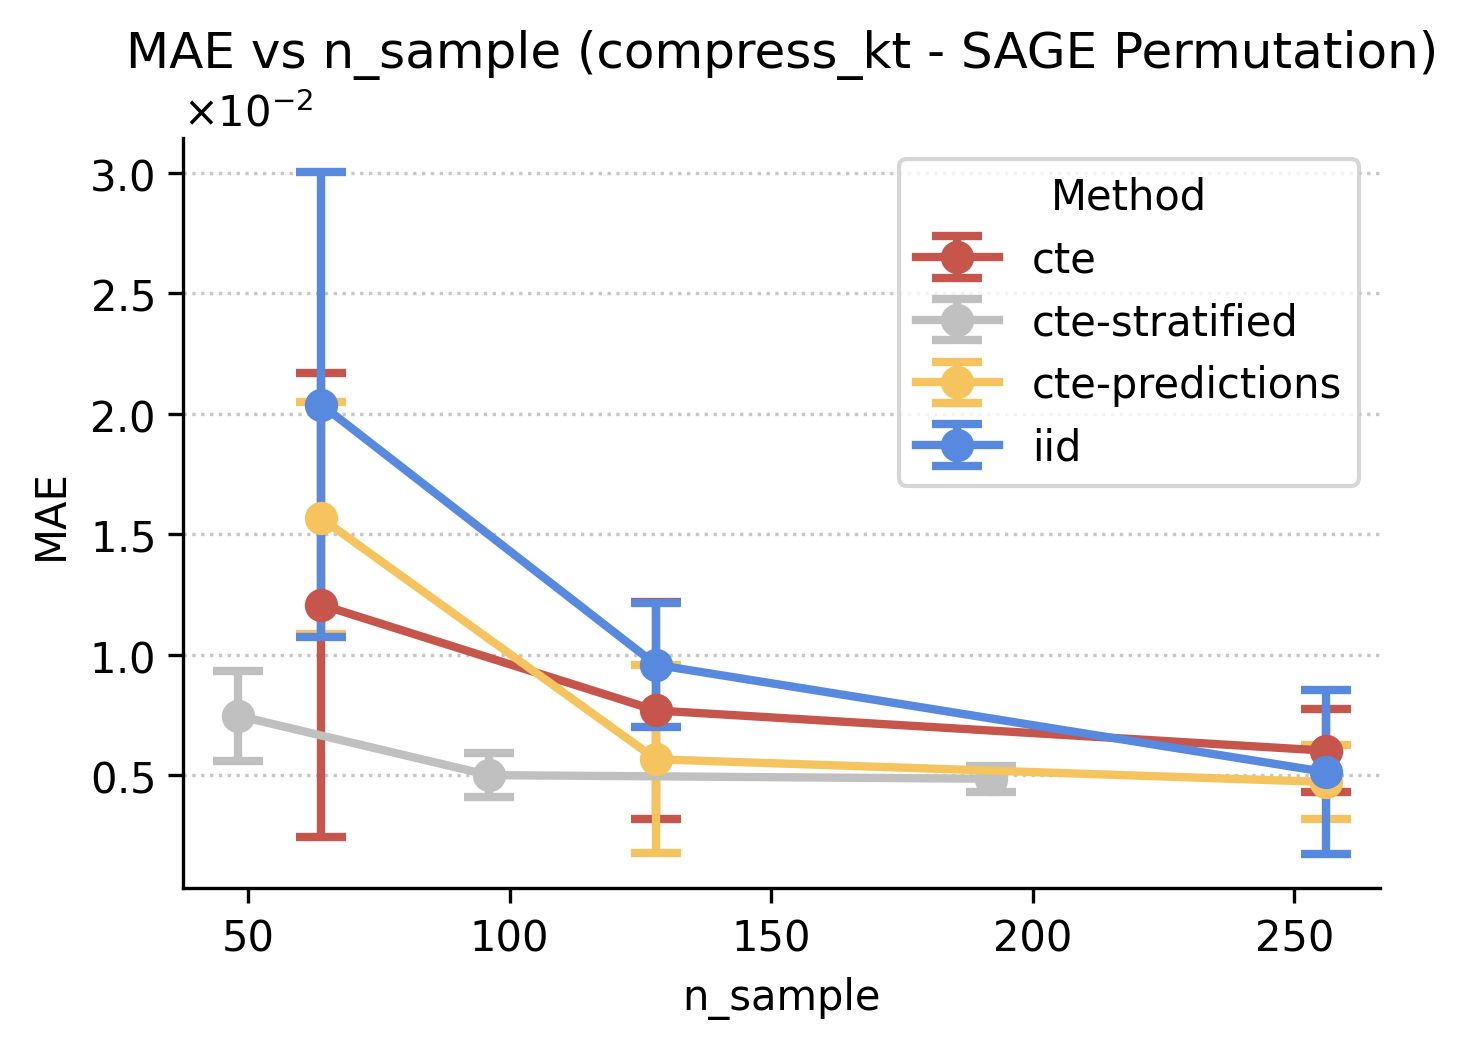

In [100]:
from matplotlib.ticker import ScalarFormatter

fig, ax = plt.subplots(figsize=(4.8, 3.6), dpi=300)

ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
ax.ticklabel_format(axis='y', style='sci', scilimits=(-2, 2))

colors = {
    "iid_sage_permutation": "#578ade",
    "cte_sage_permutation": "#c6554c",
    "cte_stratified_sage_permutation": "#c0c0c0",
    "cte_with_predictions_sage_permutation": "#F5C45E",
}

for method in agg_df['method'].unique():
    method_data = agg_df[agg_df['method'] == method]
    x = method_data['n_sample']
    y = method_data['mean']
    yerr = method_data['std']
    ax.errorbar(
        x=x, y=y, yerr=yerr,
        fmt='o-', label=method_labels.get(method, method), 
        color=colors.get(method, None),  
        markersize=7, capsize=6, linewidth=2, capthick = 2
    )

ax.set_xlabel("n_sample")
ax.set_ylabel("MAE")
ax.set_title("MAE vs n_sample (compress_kt - SAGE Permutation)")
ax.legend(title="Method")
ax.grid(axis='y', linestyle='dotted', alpha=0.7)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()


SHAP + Kernel

In [101]:
times_cte_info_ = times_cte_info[
    times_cte_info['method'].isin([
        'cte_shap_kernel',
        'cte_with_predictions_shap_kernel',
        'cte_stratified_shap_kernel',
        'iid_shap_kernel'
    ])
]

In [102]:
ground_truth = values_gt['ground_truth_shap_kernel']

mae_list = []

method_indices = {method: 0 for method in values_cte.keys()}

for _, row in times_cte_info_.iterrows():
    method = row['method']
    
    current_index = method_indices[method]
    values_cte_ = values_cte[method][current_index]
    
    method_indices[method] += 1
    
    mae = metric_mae(values_cte_, ground_truth)
    mae_list.append(mae)  

times_cte_info_['mae'] = mae_list

times_cte_info_

,dataset,repeat,method,time_explanation,time_sample_choose,n_original,n_sample,g,mae
0,compas,0,cte_shap_kernel,19.240106,0.003638,1235,64,1,0.003080
4,compas,0,cte_with_predictions_shap_kernel,22.129898,0.001275,1235,64,1,0.004846
8,compas,0,cte_stratified_shap_kernel,18.329263,0.000537,1235,48,1,0.008091
12,compas,0,iid_shap_kernel,24.005514,0.000876,1235,64,1,0.009290
16,compas,1,cte_shap_kernel,24.387702,0.001647,1235,64,1,0.002690
20,compas,1,cte_with_predictions_shap_kernel,24.543231,0.001749,1235,64,1,0.003467
24,compas,1,cte_stratified_shap_kernel,19.148009,0.000579,1235,48,1,0.010619
28,compas,1,iid_shap_kernel,24.966167,0.000051,1235,64,1,0.009542
32,compas,2,cte_shap_kernel,25.289408,0.001670,1235,64,1,0.004334
36,compas,2,cte_with_predictions_shap_kernel,25.082440,0.002057,1235,64,1,0.003933


In [103]:
import pandas as pd
import matplotlib.pyplot as plt

agg_df = times_cte_info_.groupby(['method', 'n_sample']).agg(
    mean=('mae', 'mean'),
    std=('mae', 'std')
).reset_index()

method_labels = {
    "iid_shap_kernel": "iid",
    "cte_shap_kernel": "cte",
    "cte_with_predictions_shap_kernel": "cte-predictions",
    "cte_stratified_shap_kernel": "cte-stratified",
}

label=method_labels.get(method, method)

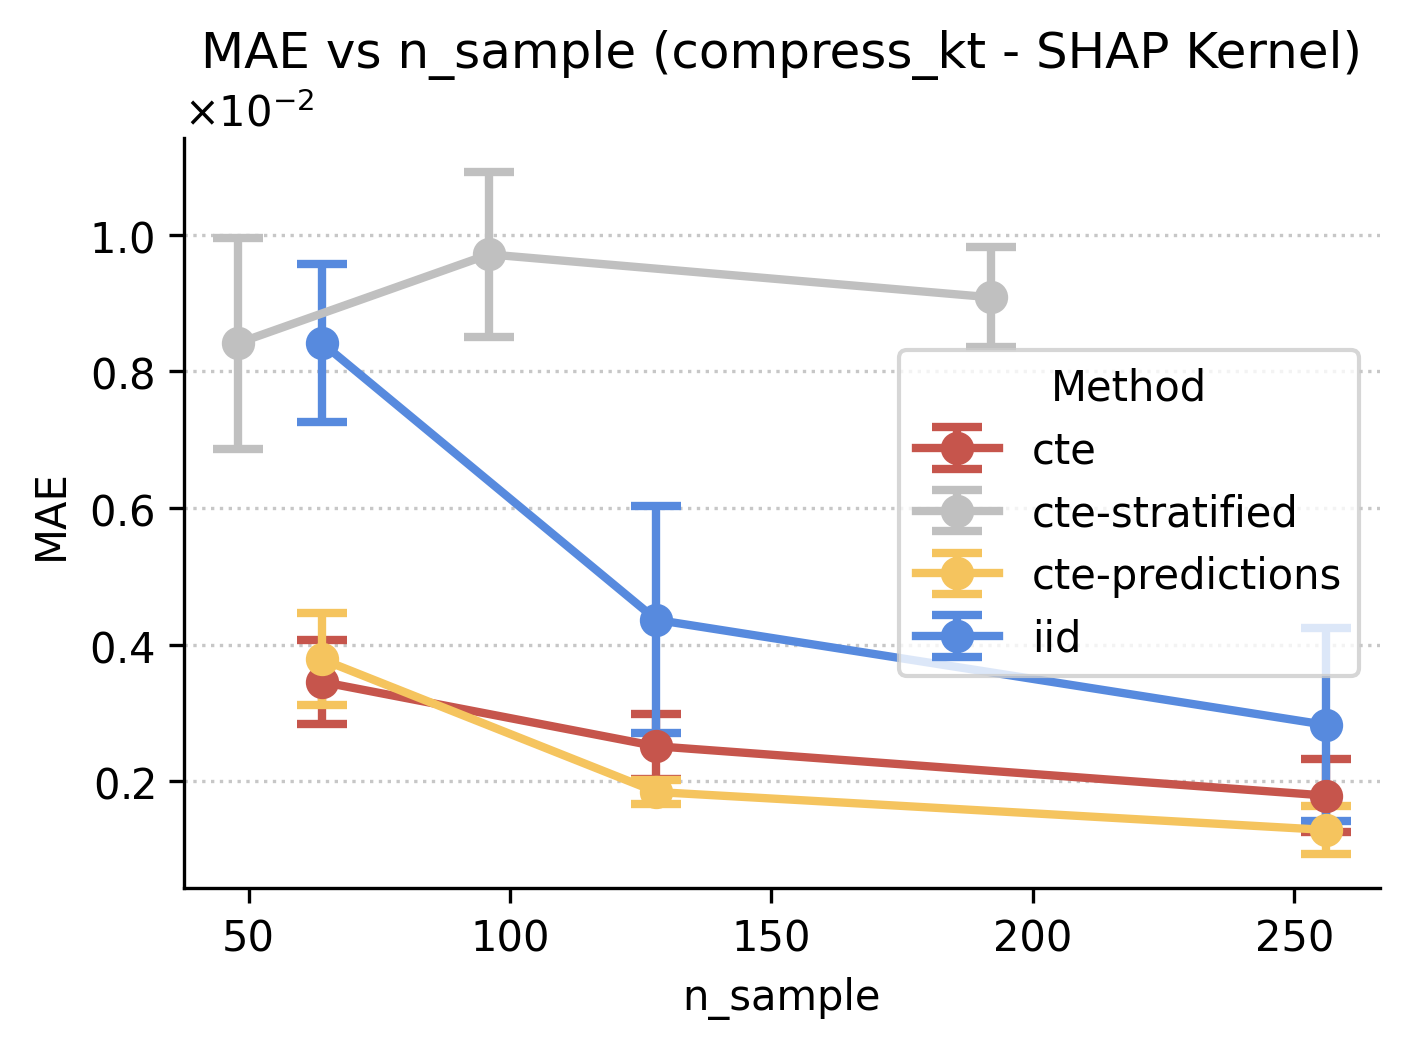

In [104]:
from matplotlib.ticker import ScalarFormatter

fig, ax = plt.subplots(figsize=(4.8, 3.6), dpi=300)

ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
ax.ticklabel_format(axis='y', style='sci', scilimits=(-2, 2))

colors = {
    "iid_shap_kernel": "#578ade",
    "cte_shap_kernel": "#c6554c",
    "cte_stratified_shap_kernel": "#c0c0c0",
    "cte_with_predictions_shap_kernel": "#F5C45E",
}

for method in agg_df['method'].unique():
    method_data = agg_df[agg_df['method'] == method]
    x = method_data['n_sample']
    y = method_data['mean']
    yerr = method_data['std']
    ax.errorbar(
        x=x, y=y, yerr=yerr,
        fmt='o-', label=method_labels.get(method, method), 
        color=colors.get(method, None),  
        markersize=7, capsize=6, linewidth=2, capthick = 2
    )

ax.set_xlabel("n_sample")
ax.set_ylabel("MAE")
ax.set_title("MAE vs n_sample (compress_kt - SHAP Kernel)")
ax.legend(title="Method")
ax.grid(axis='y', linestyle='dotted', alpha=0.7)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()
